In [ ]:
"""
02_training_analysis.ipynb
===========================
Copy each section between # %% markers into separate notebook cells.
Update EXP_DIR to your actual experiment directory.
"""

# 02 - Training Analysis

In [12]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─── UPDATE THIS PATH ───
EXP_DIR = "../training_logs/exp_001_yolo26s_full_finetune"
# ─────────────────────────

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

COLORS = {
    "bike": "#2196F3",
    "helmet": "#4CAF50",
    "no-helmet": "#F44336",
    "number-plate": "#FF9800",
}

SAVE_DIR = os.path.join(EXP_DIR, "plots", "custom")
os.makedirs(SAVE_DIR, exist_ok=True)


def save_fig(fig, name):
    fig.savefig(os.path.join(SAVE_DIR, f"{name}.png"), dpi=150, bbox_inches="tight")
    fig.savefig(os.path.join(SAVE_DIR, f"{name}.pdf"), bbox_inches="tight")
    print(f"Saved: {name}.png / .pdf")

In [13]:
# Load Ultralytics results.csv
results_csv = os.path.join(EXP_DIR, "metrics", "results.csv")
if not os.path.exists(results_csv):
    # Try yolo_output subdirectory
    results_csv = os.path.join(EXP_DIR, "yolo_output", "results.csv")

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()
print(f"Loaded results.csv: {len(df)} epochs")
print(f"Columns: {list(df.columns)}")

# Load custom metrics
custom_path = os.path.join(EXP_DIR, "metrics", "custom_metrics.json")
custom = None
if os.path.exists(custom_path):
    with open(custom_path) as f:
        custom = json.load(f)
    print(f"Loaded custom_metrics.json: {custom.get('total_epochs_run', '?')} epochs")
    print(f"Best epoch: {custom.get('best_epoch', '?')}")
    print(f"Early stopped: {custom.get('early_stopped', '?')}")
    print(f"Training time: {custom.get('training_time_seconds', 0)/60:.1f} min")
else:
    print("custom_metrics.json not found — gradient/weight plots will be skipped")

Loaded results.csv: 50 epochs
Columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
Loaded custom_metrics.json: 50 epochs
Best epoch: 47
Early stopped: False
Training time: 88.8 min


Saved: 01_loss_curves.png / .pdf


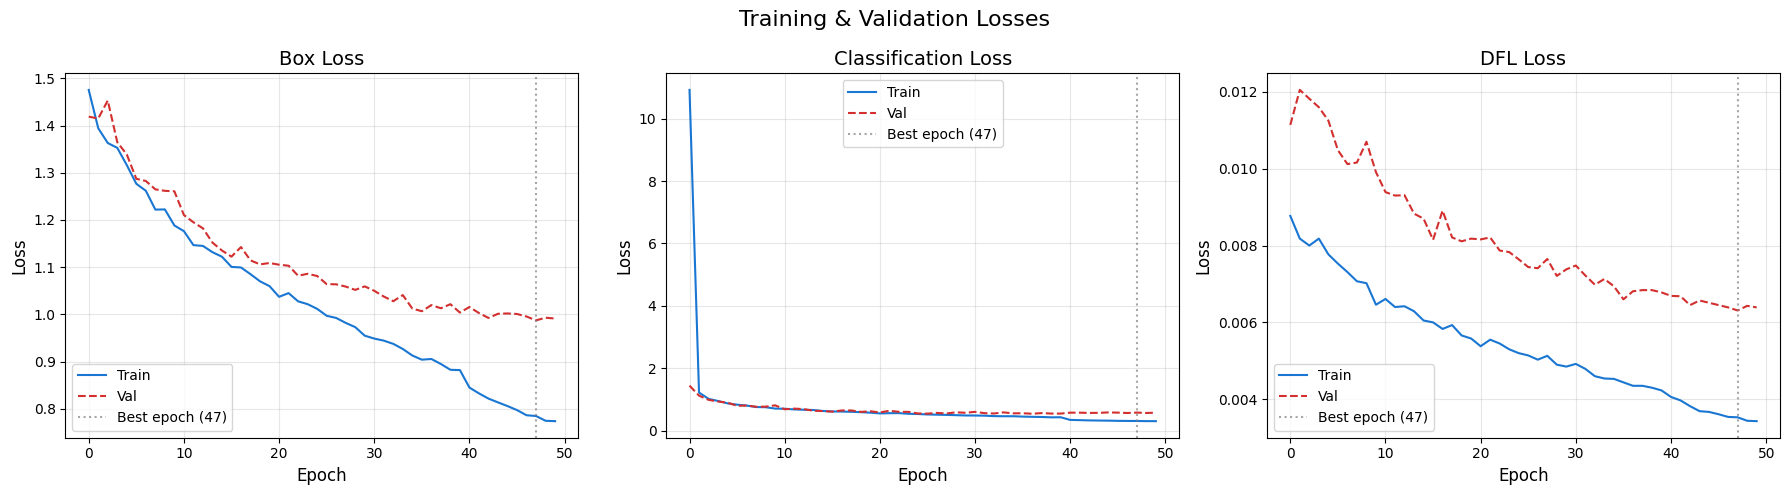

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

loss_pairs = [
    ("train/box_loss", "val/box_loss", "Box Loss"),
    ("train/cls_loss", "val/cls_loss", "Classification Loss"),
    ("train/dfl_loss", "val/dfl_loss", "DFL Loss"),
]

for ax, (train_col, val_col, title) in zip(axes, loss_pairs):
    if train_col in df.columns:
        ax.plot(df.index, df[train_col], label="Train", color="#1976D2", linewidth=1.5)
    if val_col in df.columns:
        ax.plot(df.index, df[val_col], label="Val", color="#D32F2F", linewidth=1.5, linestyle="--")

    # Mark best epoch
    if custom and "best_epoch" in custom:
        ax.axvline(custom["best_epoch"], color="gray", linestyle=":", alpha=0.7, label=f"Best epoch ({custom['best_epoch']})")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.legend()

fig.suptitle("Training & Validation Losses", fontsize=16)
fig.tight_layout()
save_fig(fig, "01_loss_curves")
plt.show()

Saved: 02_mAP_convergence.png / .pdf


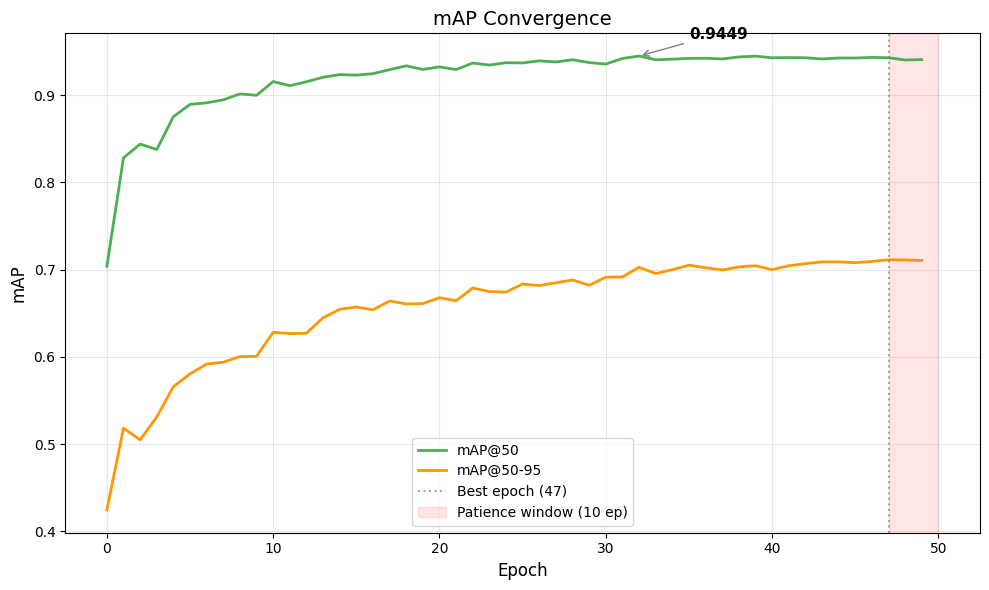

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

map50_col = [c for c in df.columns if "mAP50" in c and "mAP50-95" not in c]
map5095_col = [c for c in df.columns if "mAP50-95" in c]

if map50_col:
    ax.plot(df.index, df[map50_col[0]], label="mAP@50", color="#4CAF50", linewidth=2)
if map5095_col:
    ax.plot(df.index, df[map5095_col[0]], label="mAP@50-95", color="#FF9800", linewidth=2)

# Mark best epoch
if custom and "best_epoch" in custom:
    best = custom["best_epoch"]
    ax.axvline(best, color="gray", linestyle=":", alpha=0.7, label=f"Best epoch ({best})")

    # Shade patience window
    patience = 10
    ax.axvspan(best, min(best + patience, len(df)), alpha=0.1, color="red", label=f"Patience window ({patience} ep)")

# Annotate best values
if map50_col:
    best_val = df[map50_col[0]].max()
    best_idx = df[map50_col[0]].idxmax()
    ax.annotate(f"{best_val:.4f}", xy=(best_idx, best_val),
                xytext=(best_idx + 3, best_val + 0.02),
                arrowprops=dict(arrowstyle="->", color="gray"),
                fontsize=11, fontweight="bold")

ax.set_xlabel("Epoch")
ax.set_ylabel("mAP")
ax.set_title("mAP Convergence")
ax.legend()
fig.tight_layout()
save_fig(fig, "02_mAP_convergence")
plt.show()

Saved: 03_precision_recall.png / .pdf


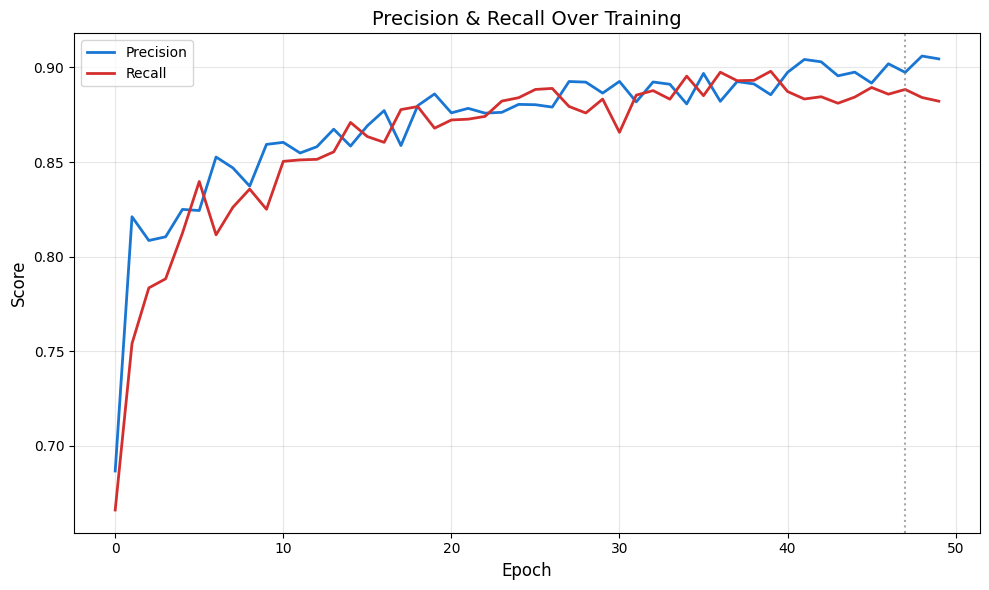

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

prec_col = [c for c in df.columns if "precision" in c.lower()]
rec_col = [c for c in df.columns if "recall" in c.lower()]

if prec_col:
    ax.plot(df.index, df[prec_col[0]], label="Precision", color="#1976D2", linewidth=2)
if rec_col:
    ax.plot(df.index, df[rec_col[0]], label="Recall", color="#D32F2F", linewidth=2)

if custom and "best_epoch" in custom:
    ax.axvline(custom["best_epoch"], color="gray", linestyle=":", alpha=0.7)

ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_title("Precision & Recall Over Training")
ax.legend()
fig.tight_layout()
save_fig(fig, "03_precision_recall")
plt.show()

Saved: 04_per_class_ap.png / .pdf


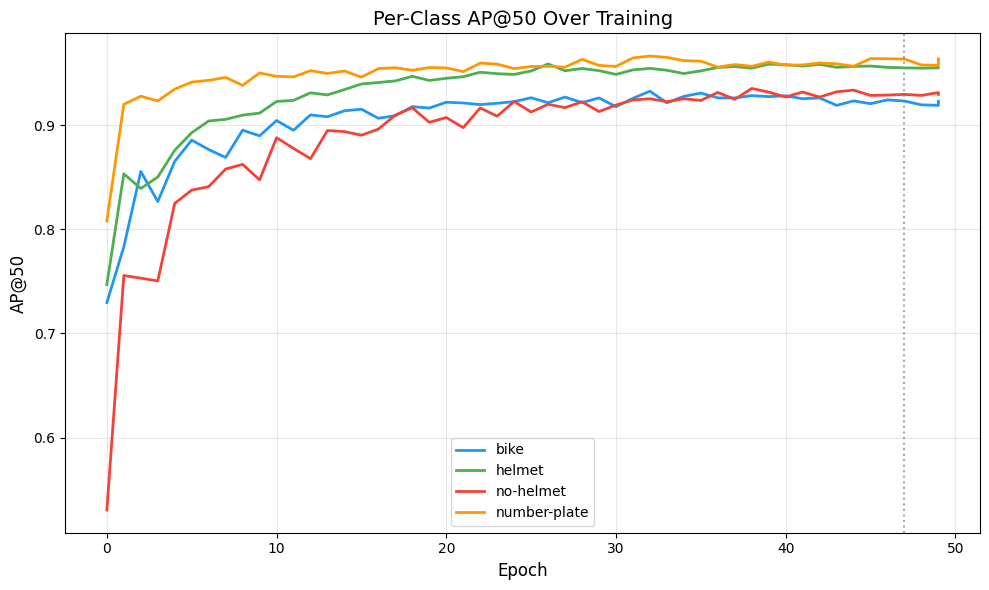

In [17]:
if custom and custom.get("per_class_ap"):
    fig, ax = plt.subplots(figsize=(10, 6))

    per_class = custom["per_class_ap"]
    epochs = [entry["epoch"] for entry in per_class]

    for cls_name, color in COLORS.items():
        ap_values = []
        for entry in per_class:
            if cls_name in entry and "ap50" in entry[cls_name]:
                ap_values.append(entry[cls_name]["ap50"])
            else:
                ap_values.append(0)

        if any(v > 0 for v in ap_values):
            ax.plot(epochs, ap_values, label=cls_name, color=color, linewidth=2)

    if custom.get("best_epoch") is not None:
        ax.axvline(custom["best_epoch"], color="gray", linestyle=":", alpha=0.7)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("AP@50")
    ax.set_title("Per-Class AP@50 Over Training")
    ax.legend()
    fig.tight_layout()
    save_fig(fig, "04_per_class_ap")
    plt.show()
else:
    print("Per-class AP data not available in custom_metrics.json")

Saved: 05_learning_rate.png / .pdf


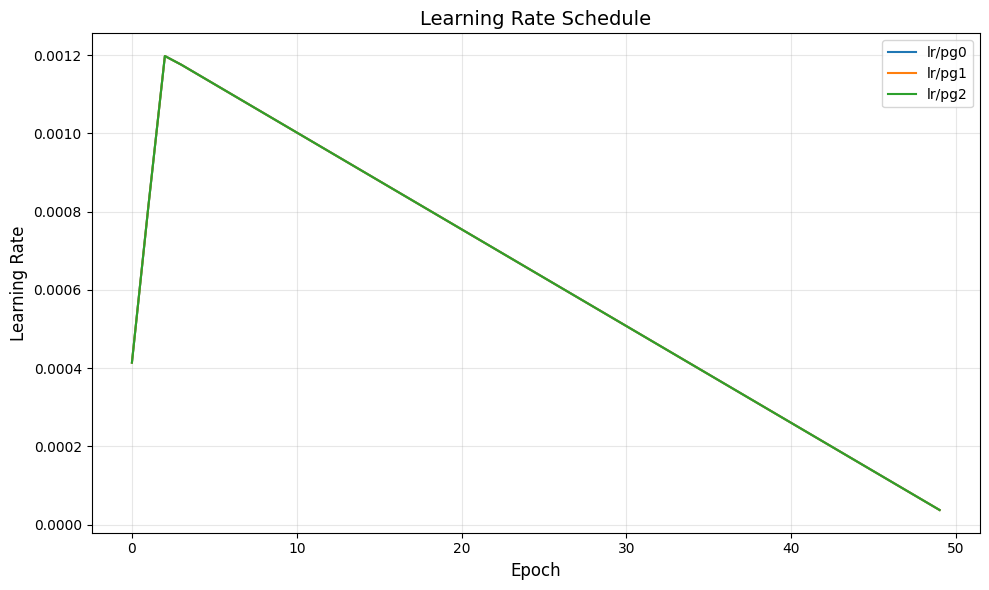

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

lr_cols = [c for c in df.columns if "lr/" in c or "lr" in c.lower()]
if lr_cols:
    for col in lr_cols:
        ax.plot(df.index, df[col], label=col, linewidth=1.5)
elif custom and custom.get("learning_rates"):
    lr_data = custom["learning_rates"]
    epochs = [entry["epoch"] for entry in lr_data]
    for key in ["pg0", "pg1", "pg2"]:
        values = [entry.get(key, 0) for entry in lr_data]
        if any(v > 0 for v in values):
            ax.plot(epochs, values, label=key, linewidth=1.5)

ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedule")
ax.legend()
fig.tight_layout()
save_fig(fig, "05_learning_rate")
plt.show()

Saved: 06_gradient_norms.png / .pdf


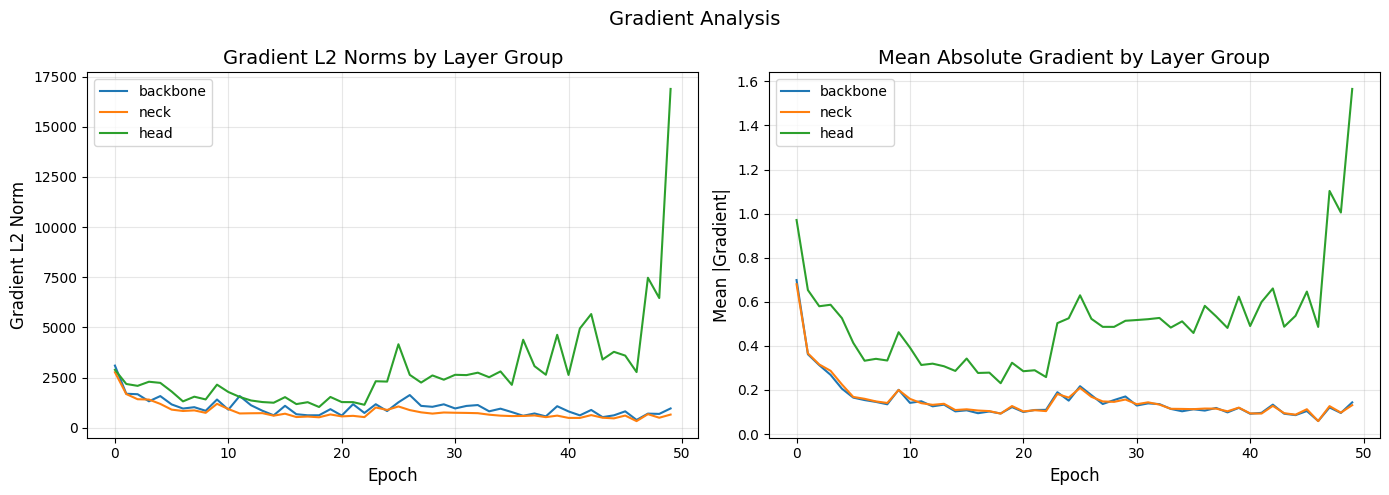

In [19]:
if custom and custom.get("gradients"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    grad_data = custom["gradients"]
    epochs = [entry["epoch"] for entry in grad_data]

    # L2 norms
    ax = axes[0]
    for group in ["backbone", "neck", "head"]:
        values = [entry.get(group, {}).get("l2_norm", 0) for entry in grad_data]
        if any(v > 0 for v in values):
            ax.plot(epochs, values, label=group, linewidth=1.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Gradient L2 Norm")
    ax.set_title("Gradient L2 Norms by Layer Group")
    ax.legend()

    # Mean absolute
    ax = axes[1]
    for group in ["backbone", "neck", "head"]:
        values = [entry.get(group, {}).get("mean_abs", 0) for entry in grad_data]
        if any(v > 0 for v in values):
            ax.plot(epochs, values, label=group, linewidth=1.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean |Gradient|")
    ax.set_title("Mean Absolute Gradient by Layer Group")
    ax.legend()

    fig.suptitle("Gradient Analysis", fontsize=14)
    fig.tight_layout()
    save_fig(fig, "06_gradient_norms")
    plt.show()
else:
    print("Gradient data not available")

Saved: 07_weight_evolution.png / .pdf


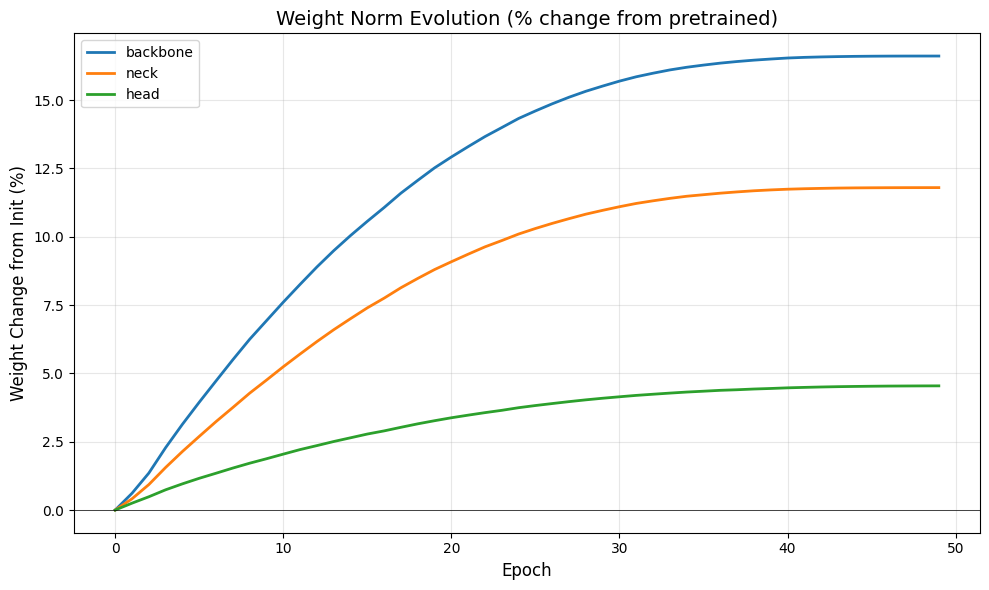

In [20]:
if custom and custom.get("weight_norms"):
    fig, ax = plt.subplots(figsize=(10, 6))

    wn_data = custom["weight_norms"]
    epochs = [entry["epoch"] for entry in wn_data]

    for group in ["backbone", "neck", "head"]:
        key = f"{group}_l2"
        values = [entry.get(key, 0) for entry in wn_data]
        if any(v > 0 for v in values):
            # Normalize: show relative change from epoch 0
            if values[0] > 0:
                relative = [(v - values[0]) / values[0] * 100 for v in values]
                ax.plot(epochs, relative, label=group, linewidth=2)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Weight Change from Init (%)")
    ax.set_title("Weight Norm Evolution (% change from pretrained)")
    ax.legend()
    ax.axhline(0, color="black", linewidth=0.5)
    fig.tight_layout()
    save_fig(fig, "07_weight_evolution")
    plt.show()
else:
    print("Weight norm data not available")

Saved: 08_epoch_timing.png / .pdf


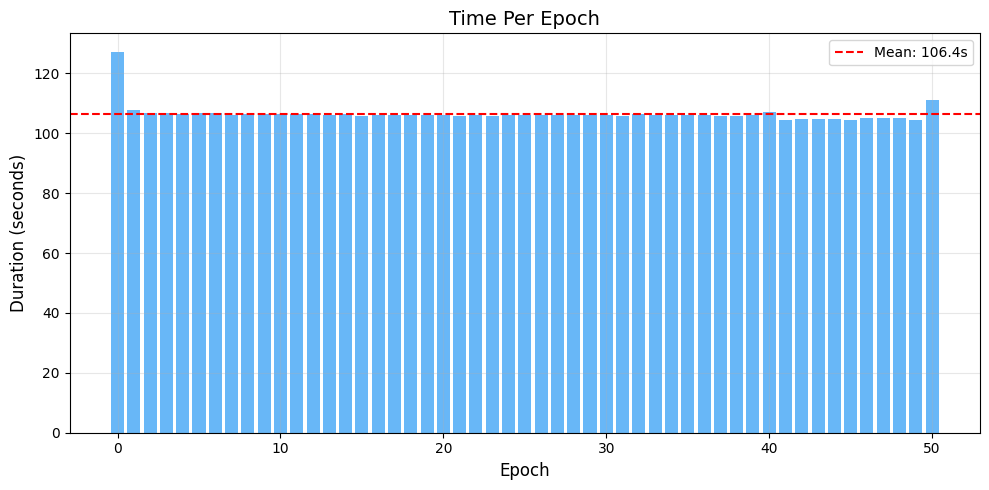

: 

In [ ]:
if custom and custom.get("epoch_durations_seconds"):
    fig, ax = plt.subplots(figsize=(10, 5))

    durations = custom["epoch_durations_seconds"]
    ax.bar(range(len(durations)), durations, color="#42A5F5", alpha=0.8)
    ax.axhline(np.mean(durations), color="red", linestyle="--",
               label=f"Mean: {np.mean(durations):.1f}s")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Duration (seconds)")
    ax.set_title("Time Per Epoch")
    ax.legend()
    fig.tight_layout()
    save_fig(fig, "08_epoch_timing")
    plt.show()
else:
    print("Epoch timing data not available")

In [11]:
print("=" * 60)
print("  TRAINING SUMMARY")
print("=" * 60)

if map50_col:
    print(f"  Best mAP@50:     {df[map50_col[0]].max():.4f} (epoch {df[map50_col[0]].idxmax()})")
if map5095_col:
    print(f"  Best mAP@50-95:  {df[map5095_col[0]].max():.4f} (epoch {df[map5095_col[0]].idxmax()})")
if prec_col:
    print(f"  Best Precision:  {df[prec_col[0]].max():.4f}")
if rec_col:
    print(f"  Best Recall:     {df[rec_col[0]].max():.4f}")
print(f"  Total epochs:    {len(df)}")

if custom:
    print(f"  Early stopped:   {custom.get('early_stopped', 'N/A')}")
    print(f"  Training time:   {custom.get('training_time_seconds', 0)/60:.1f} min")

# Final loss values
print(f"\n  Final losses:")
for col in df.columns:
    if "loss" in col.lower():
        print(f"    {col}: {df[col].iloc[-1]:.4f}")

  TRAINING SUMMARY
  Best mAP@50:     0.9475 (epoch 32)
  Best mAP@50-95:  0.7207 (epoch 47)
  Best Precision:  0.9063
  Best Recall:     0.9078
  Total epochs:    50
  Early stopped:   False
  Training time:   353.2 min

  Final losses:
    train/box_loss: 0.7478
    train/cls_loss: 0.2854
    train/dfl_loss: 0.0036
    val/box_loss: 0.9424
    val/cls_loss: 0.5502
    val/dfl_loss: 0.0059
